# EfficientNet Feature Map Visualization
This notebook visualizes how an image is processed layer by layer through EfficientNetB0.
We will load an image from the face mask dataset, preprocess it, pass it through the model, and plot the feature maps (outputs) of various layers.

In [8]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPUs: []


In [ ]:
import torch

device = torch.device("cuda")

x = torch.randn(10000, 10000).to(device)
y = torch.matmul(x, x)

print(y.device)

2.20.0
False
[]


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model

# Set figure size for better visualization
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load and Preprocess the Input Image
We need an image to feed into the network. We'll pick one from the dataset, resize it to 224x224 (the default for EfficientNetB0), and apply the specific preprocessing function.

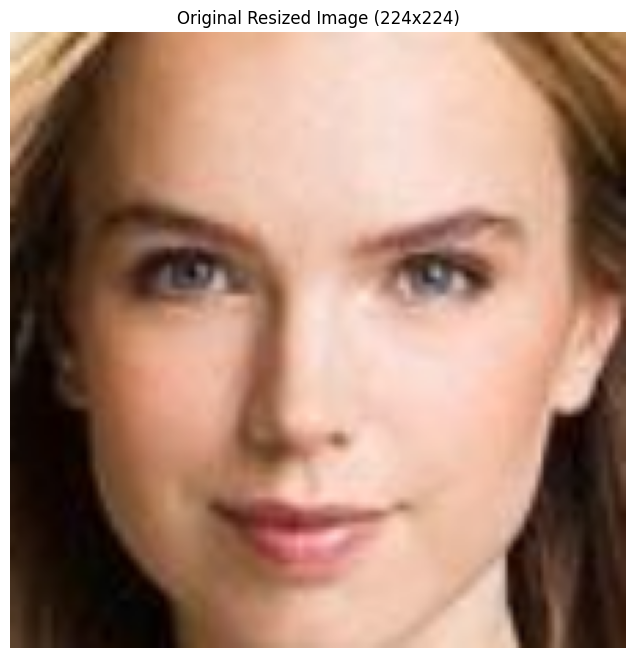

Preprocessed image shape: (1, 224, 224, 3)


In [3]:
# Load an image from the assets folder
# sample_image_path = '../assets/EfficientNetB0/image.png'
sample_image_path = '../face_mask_dataset/train\without_mask/17.png'

# Load using OpenCV
img = cv2.imread(sample_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize to 224x224
img_resized = cv2.resize(img, (224, 224))

# Plot the original resized image
plt.imshow(img_resized)
plt.title("Original Resized Image (224x224)")
plt.axis('off')
plt.show()

# Preprocess for EfficientNet (expands dims to make it a batch of 1)
img_array = np.expand_dims(img_resized, axis=0)
img_preprocessed = preprocess_input(img_array.astype(np.float32))

print("Preprocessed image shape:", img_preprocessed.shape)


## 2. Load EfficientNetB0 and Select Layers for Visualization
EfficientNet has hundreds of layers. Visualizing all of them is too much. We will extract the outputs of specific activation layers (like after certain blocks) to see how the network's understanding of the image evolves.

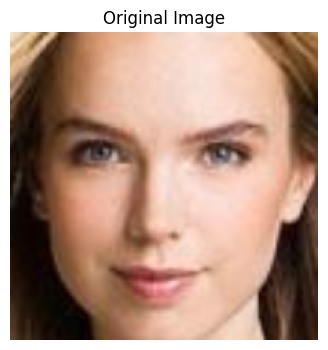

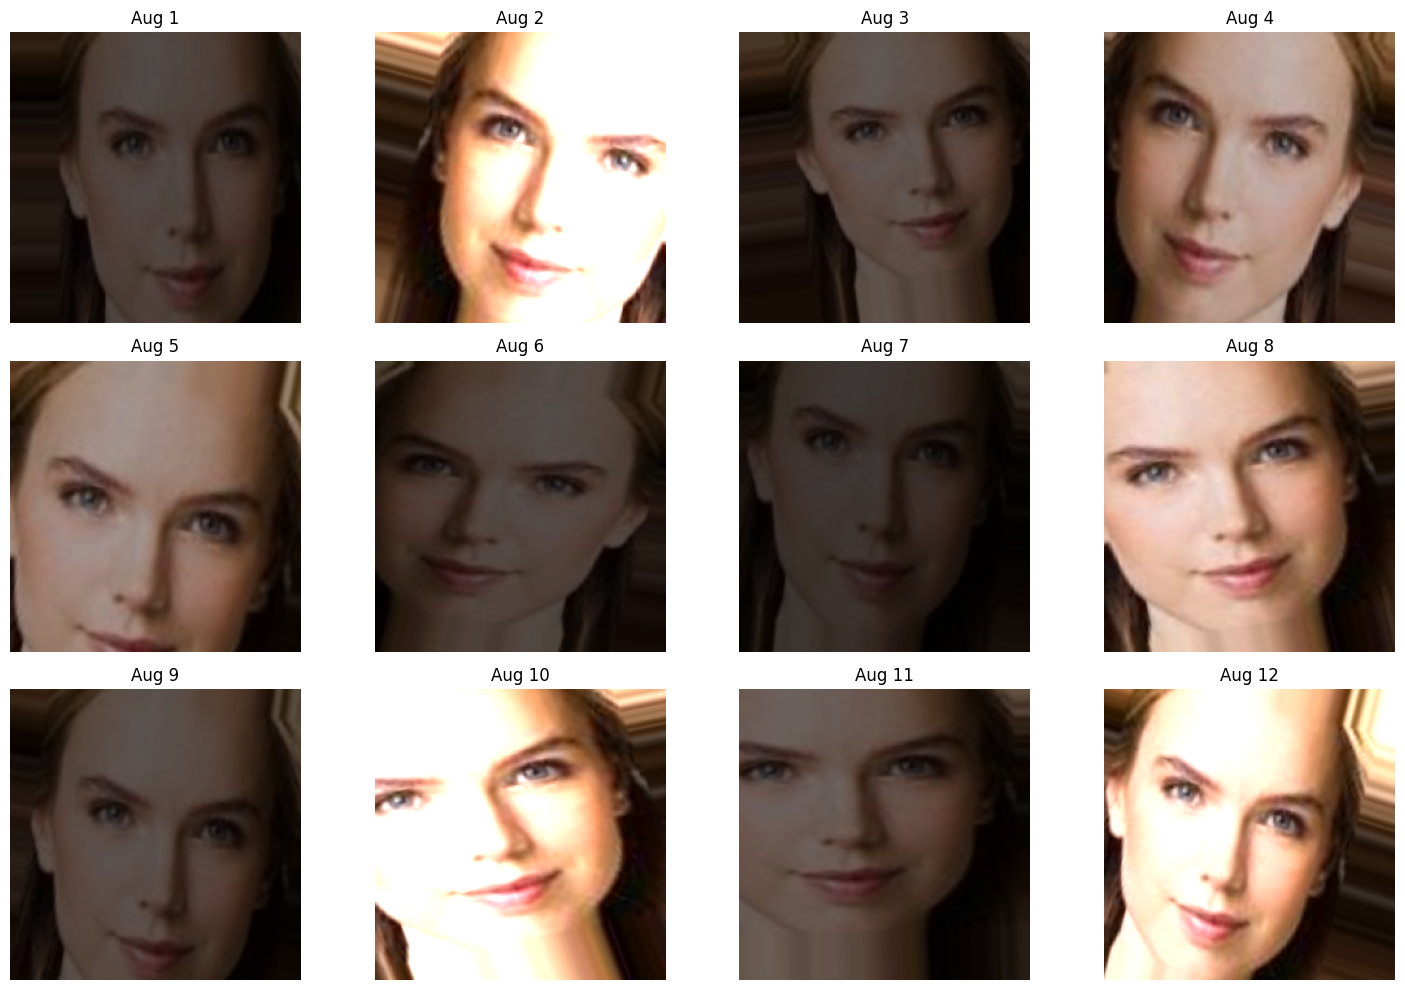

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -----------------------------
# Data Augmentation
# -----------------------------
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.2, 1.9],
    fill_mode="nearest"
)

# -----------------------------
# Load one image
# -----------------------------
sample_image_path = r'../face_mask_dataset/train/without_mask/17.png'

img = cv2.imread(sample_image_path)

if img is None:
    raise FileNotFoundError(f"Image not found: {sample_image_path}")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize
img_resized = cv2.resize(img, (380, 380))

# -----------------------------
# Show Original Image
# -----------------------------
plt.figure(figsize=(4,4))
plt.imshow(img_resized)
plt.title("Original Image")
plt.axis("off")
plt.show()

# -----------------------------
# Create batch dimension
# -----------------------------
img_array = np.expand_dims(img_resized, axis=0)

# -----------------------------
# Generate augmentations
# -----------------------------
aug_iter = datagen.flow(
    img_array,
    batch_size=1,
    shuffle=False
)

# -----------------------------
# Show augmented images
# -----------------------------
plt.figure(figsize=(15, 10))

for i in range(12):
    batch = next(aug_iter)

    plt.subplot(3, 4, i + 1)
    plt.imshow(batch[0])
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import os

with_mask_list = os.listdir('../face_mask_dataset/train/with_mask')
without_mask_list = os.listdir('../face_mask_dataset/train/without_mask')

print(len(with_mask_list))
print(len(without_mask_list))

4806
4806


In [11]:
# Load base EfficientNetB0
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# We will select activation outputs of multiple blocks to see the progression
layer_names = [
    'stem_activation',        # Early edge detection
    'block1a_activation',
    'block2a_activation',
    'block3a_activation',
    'block4a_activation',
    'block5a_activation',
    'block6a_activation',
    'block7a_activation',
    'top_activation'          # Deepest features before pooling
]

outputs = [base_model.get_layer(name).output for name in layer_names]

# Create a new model that outputs these feature maps
feature_map_model = Model(inputs=base_model.input, outputs=outputs)
feature_map_model.summary()


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 4,007,548 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

## 3. Generate Feature Maps
Now we pass our preprocessed image through this new model to get the feature maps.

In [12]:
# Predict to get the feature maps
feature_maps = feature_map_model.predict(img_preprocessed)

for layer_name, feature_map in zip(layer_names, feature_maps):
    print(f"Layer: {layer_name} | Shape: {feature_map.shape}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Layer: stem_activation | Shape: (1, 112, 112, 32)
Layer: block1a_activation | Shape: (1, 112, 112, 32)
Layer: block2a_activation | Shape: (1, 56, 56, 96)
Layer: block3a_activation | Shape: (1, 28, 28, 144)
Layer: block4a_activation | Shape: (1, 14, 14, 240)
Layer: block5a_activation | Shape: (1, 14, 14, 480)
Layer: block6a_activation | Shape: (1, 7, 7, 672)
Layer: block7a_activation | Shape: (1, 7, 7, 1152)
Layer: top_activation | Shape: (1, 7, 7, 1280)


## 4. Visualize the Feature Maps
Each layer outputs many channels (filters). We will plot the first few channels (e.g., 16 or 64) for each selected layer in a grid.

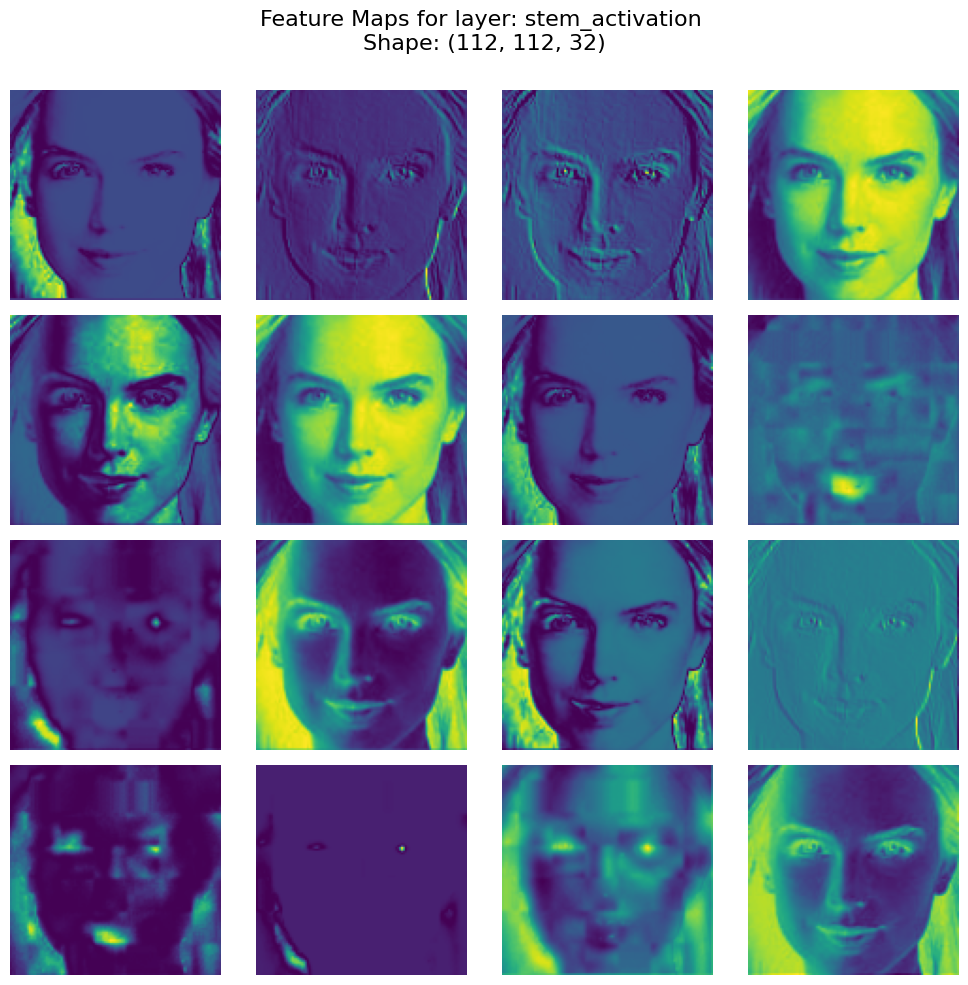

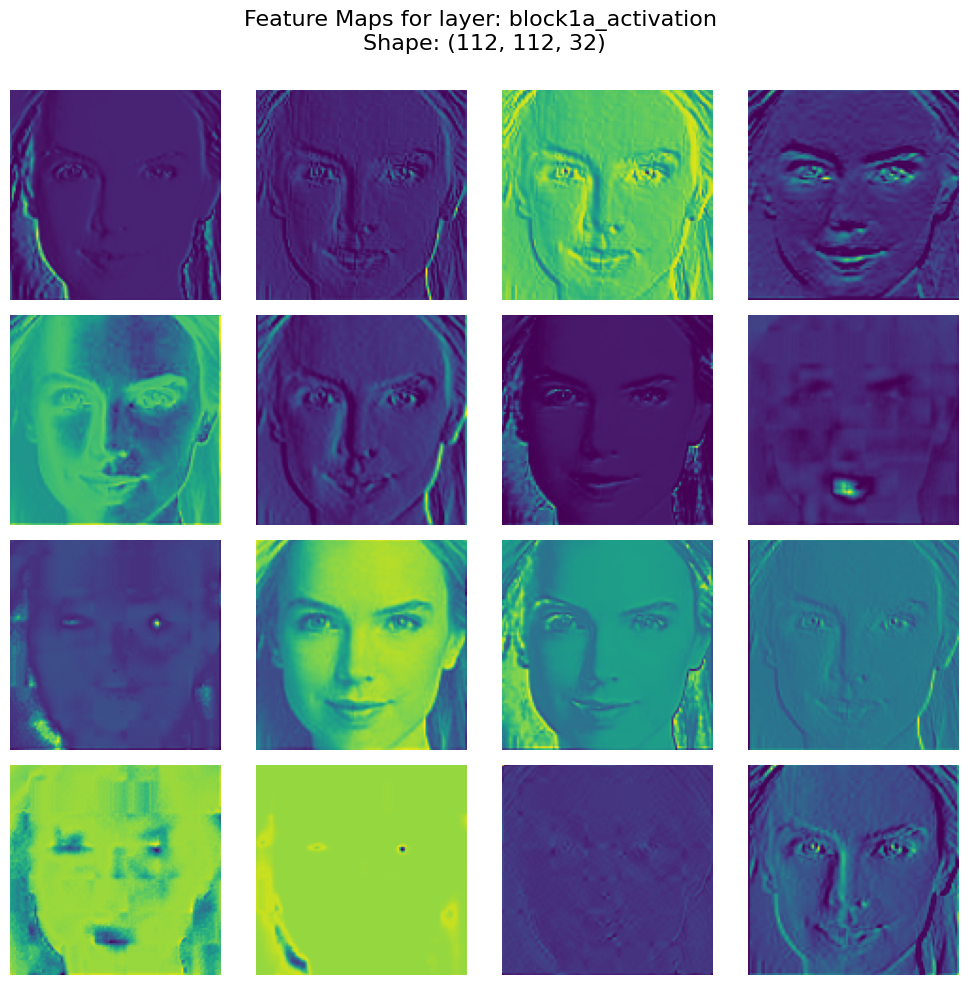

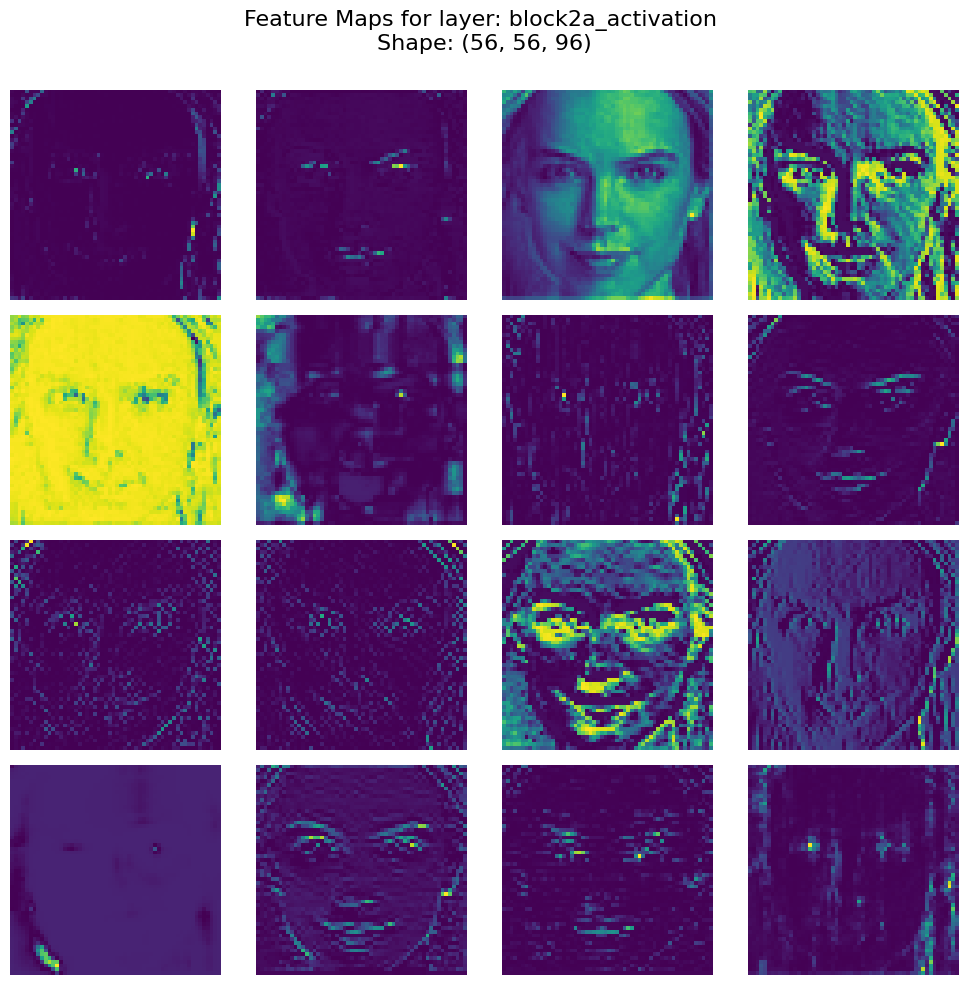

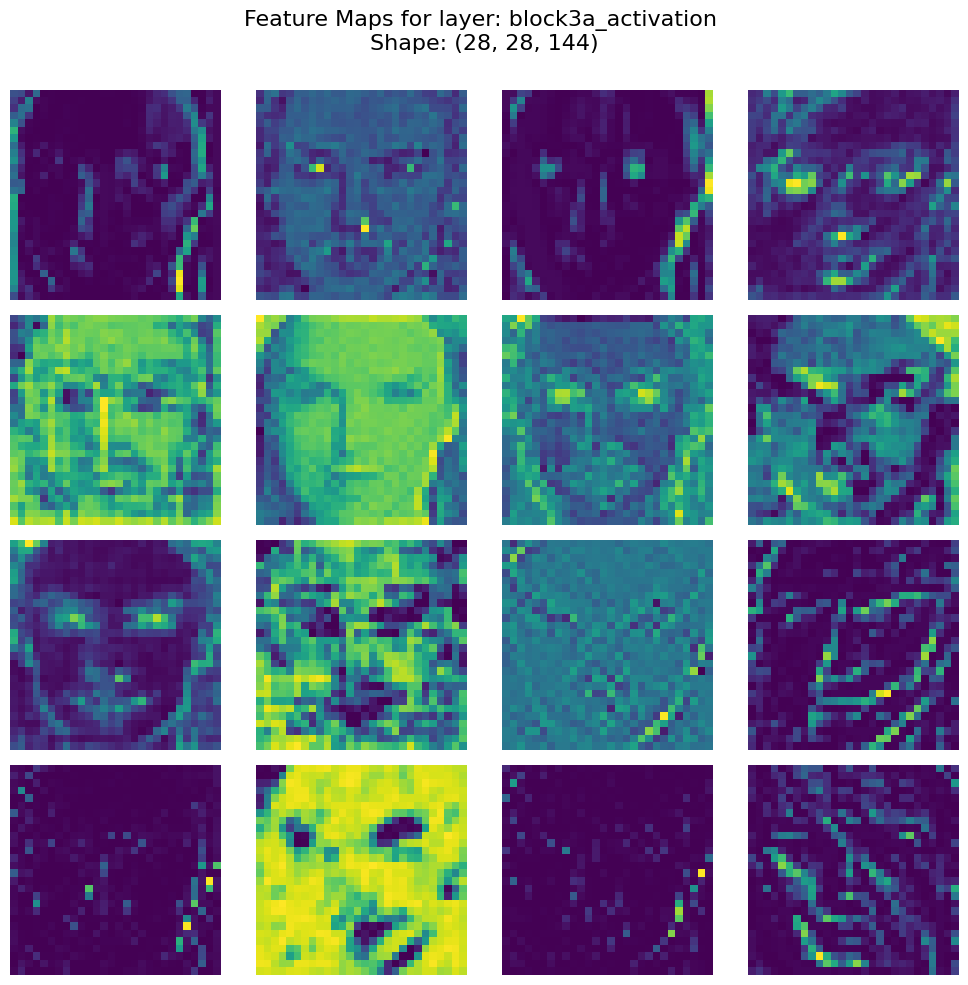

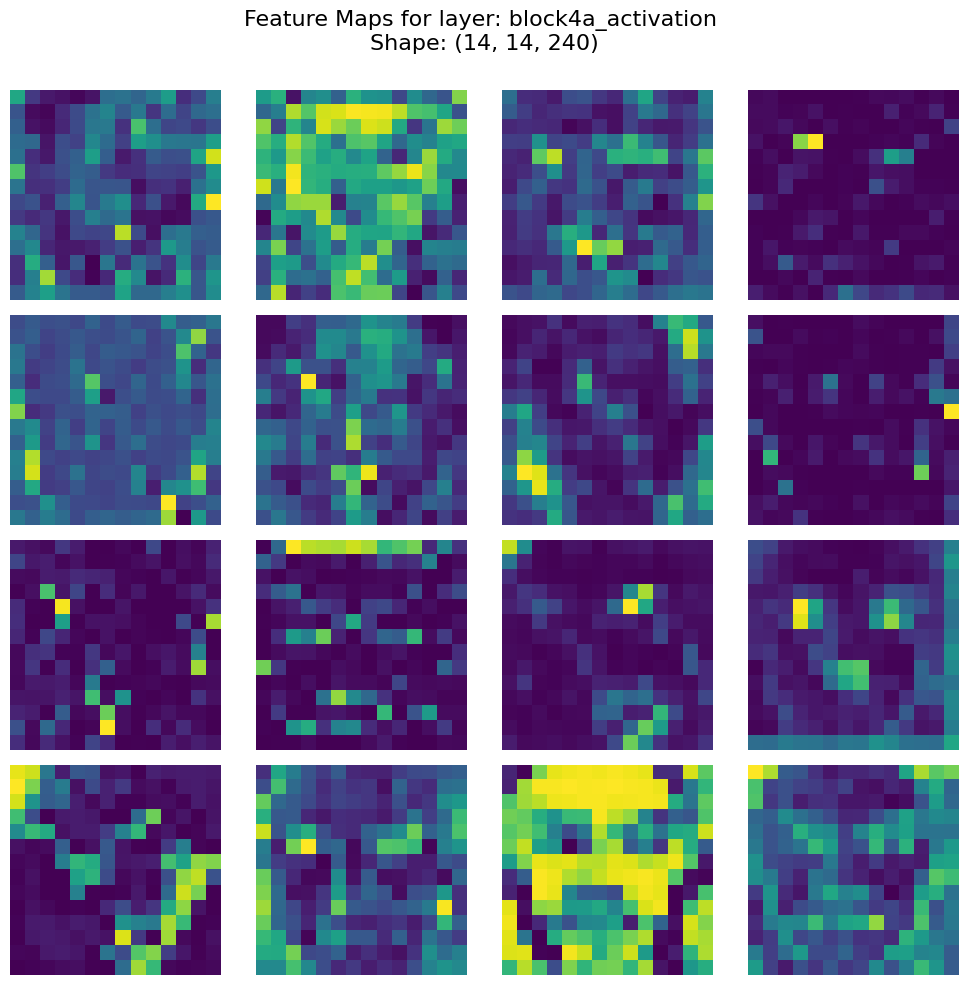

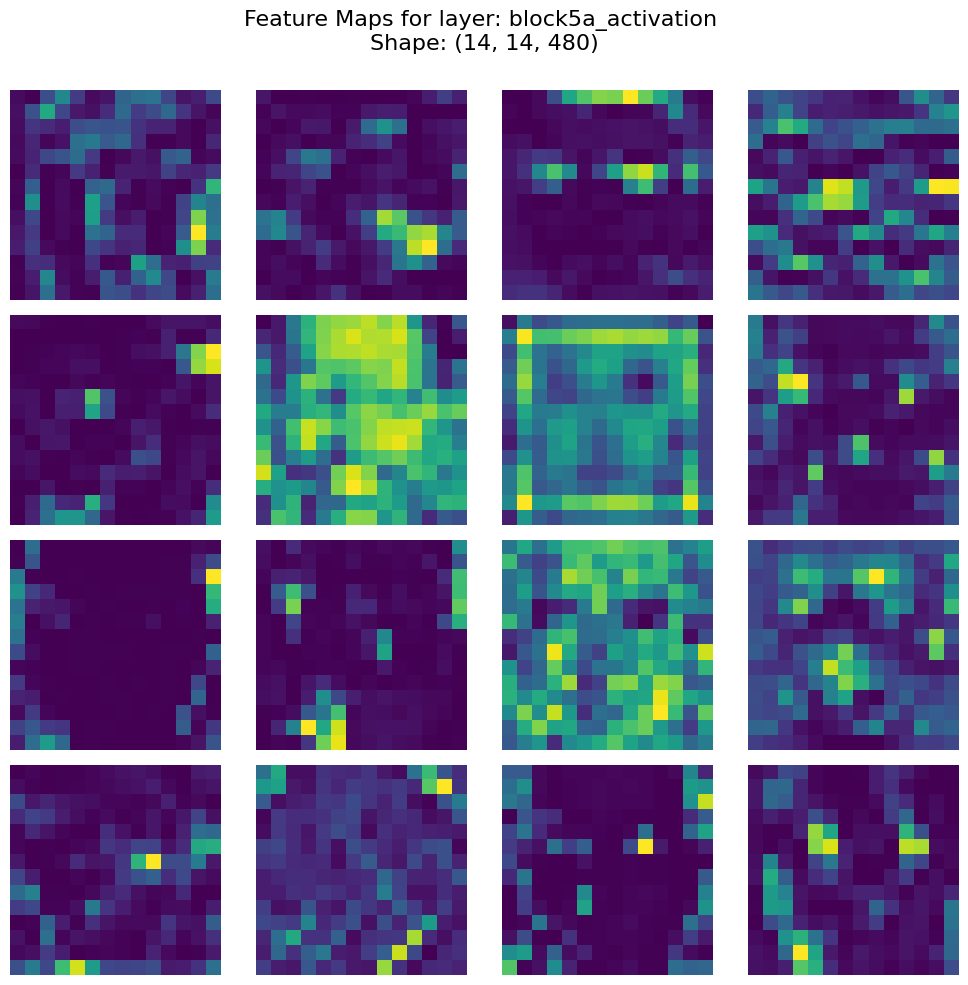

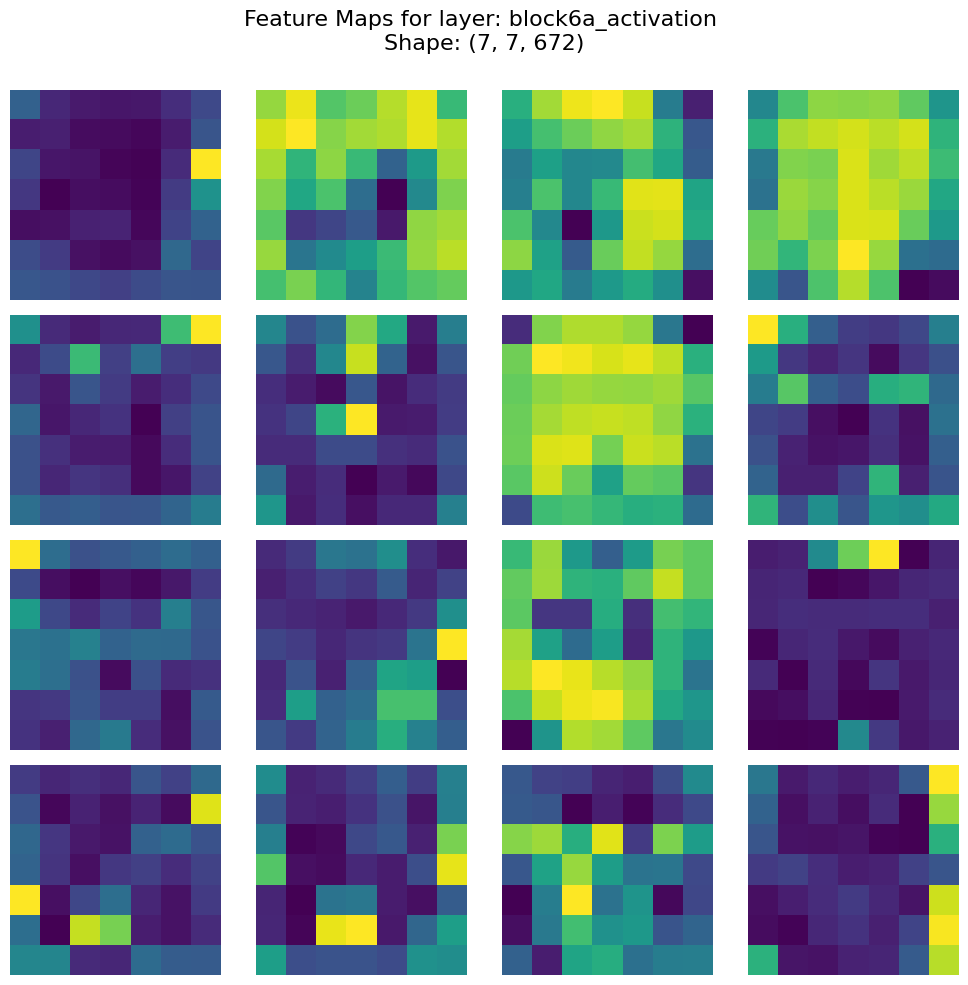

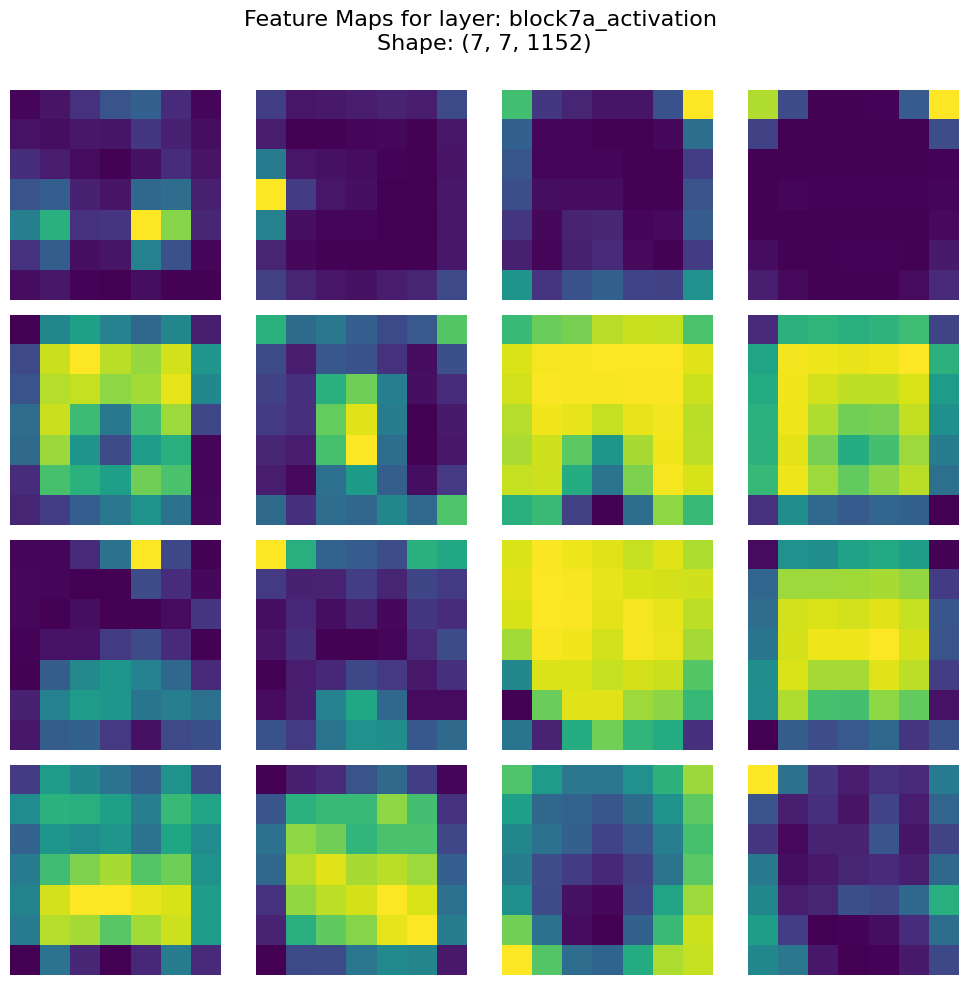

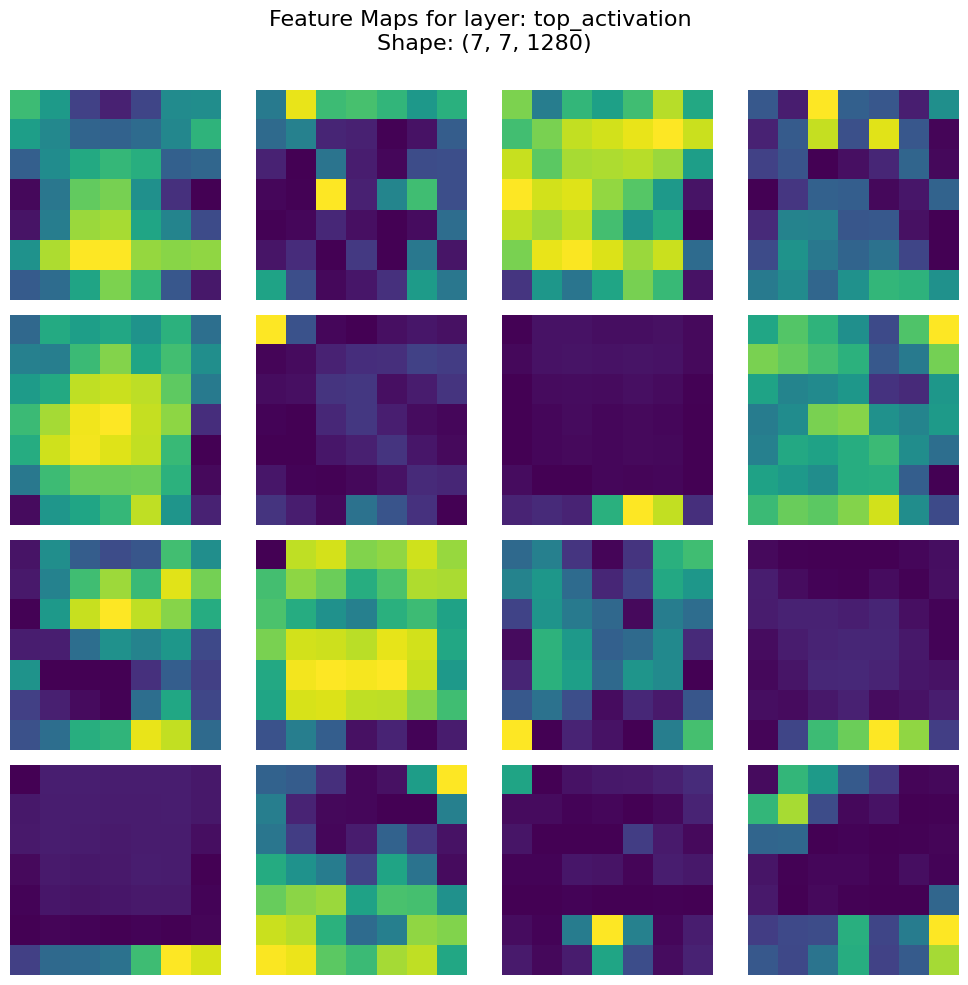

In [13]:
def plot_feature_maps(feature_maps, layer_names, max_filters=16):
    for layer_name, fmap in zip(layer_names, feature_maps):
        # fmap shape is (1, width, height, channels)
        # We drop the batch dimension
        fmap = fmap[0]
        
        n_filters = fmap.shape[-1]
        n_filters = min(n_filters, max_filters)
        
        # Determine grid size (e.g., 4x4 for 16 filters)
        size = int(np.ceil(np.sqrt(n_filters)))
        
        fig, axes = plt.subplots(size, size, figsize=(10, 10))
        fig.suptitle(f'Feature Maps for layer: {layer_name} \nShape: {fmap.shape}', fontsize=16)
        
        for i, ax in enumerate(axes.flat):
            if i < n_filters:
                # Plot the i-th channel/filter
                ax.imshow(fmap[:, :, i], cmap='viridis')
                ax.axis('off')
            else:
                ax.axis('off')
                
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()

# Plot the first 16 filters of each selected layer
plot_feature_maps(feature_maps, layer_names, max_filters=16)